In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne

from config import (
    ELECTRODE_NAMES, CLASS_NAMES, N_CLASSES,
    TMIN, TMAX, N_TIME_SUBSAMPLE, N_CWT_SCALES,
)
from preprocessing import load_raw, extract_epochs, cwt_trial, normalise_dataset

mne.set_log_level('WARNING')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Setup complete.')

Setup complete.


In [2]:
SUBJECT = 1

raw = load_raw(SUBJECT, session='T')
print(f'Channels : {raw.ch_names}')
print(f'Duration : {raw.times[-1]:.1f} s')
print(f'Sampling : {int(raw.info["sfreq"])} Hz')

c:\Users\vchagant\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Channels : ['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Oz']
Duration : 2690.1 s
Sampling : 250 Hz


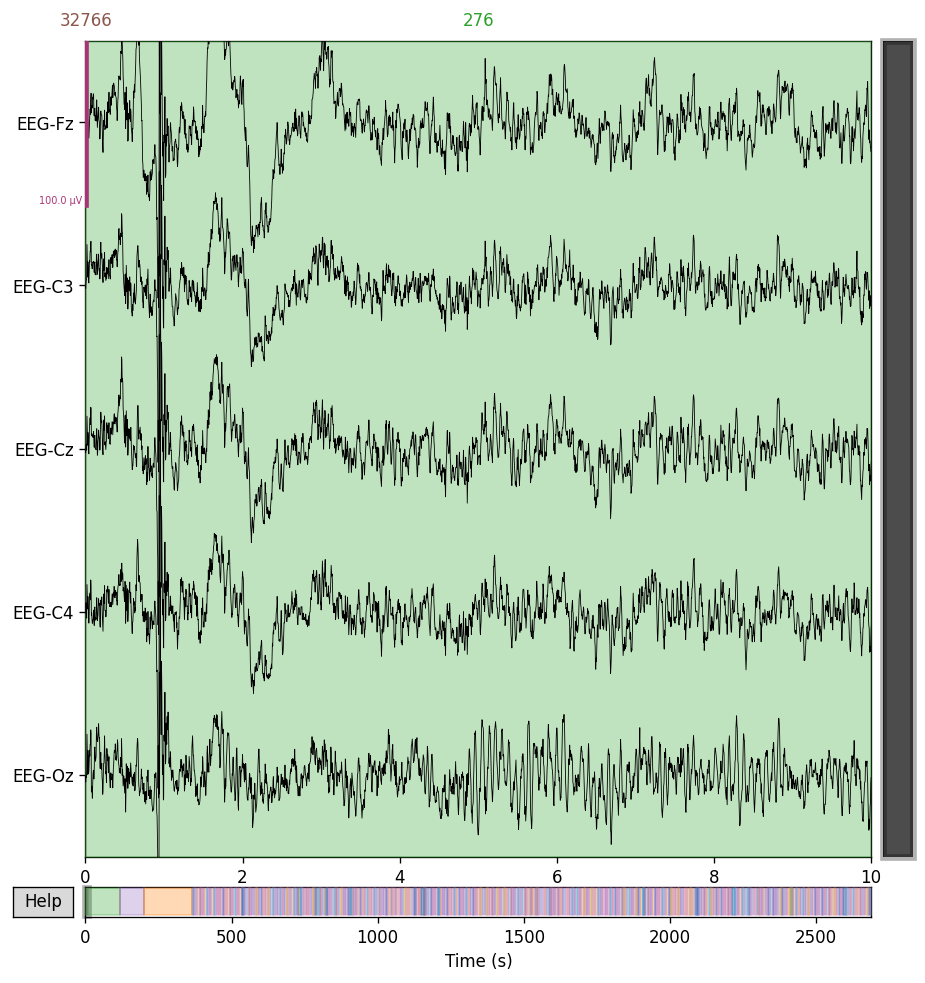

In [3]:
raw.plot(duration=10, n_channels=5, scalings=dict(eeg=50e-6),
         title=f'Subject {SUBJECT} — Raw EEG (after bandpass + notch)',
         show=True, block=True);

Trials : (288, 5, 1001)   (trials × channels × time)
Labels : (array([0, 1, 2, 3]), array([72, 72, 72, 72], dtype=int64))


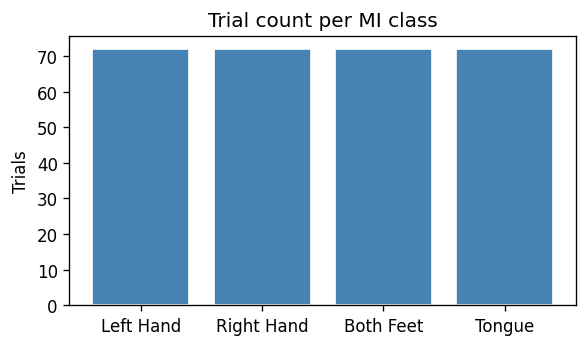

In [4]:
X_raw, y = extract_epochs(raw)
print(f'Trials : {X_raw.shape}   (trials × channels × time)')
print(f'Labels : {np.unique(y, return_counts=True)}')

fig, ax = plt.subplots(figsize=(5, 3))
counts  = [np.sum(y == c) for c in range(N_CLASSES)]
ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
ax.set_title('Trial count per MI class'); ax.set_ylabel('Trials')
plt.tight_layout(); plt.show()

## Single-Trial CWT Scalogram (raw → CWT)

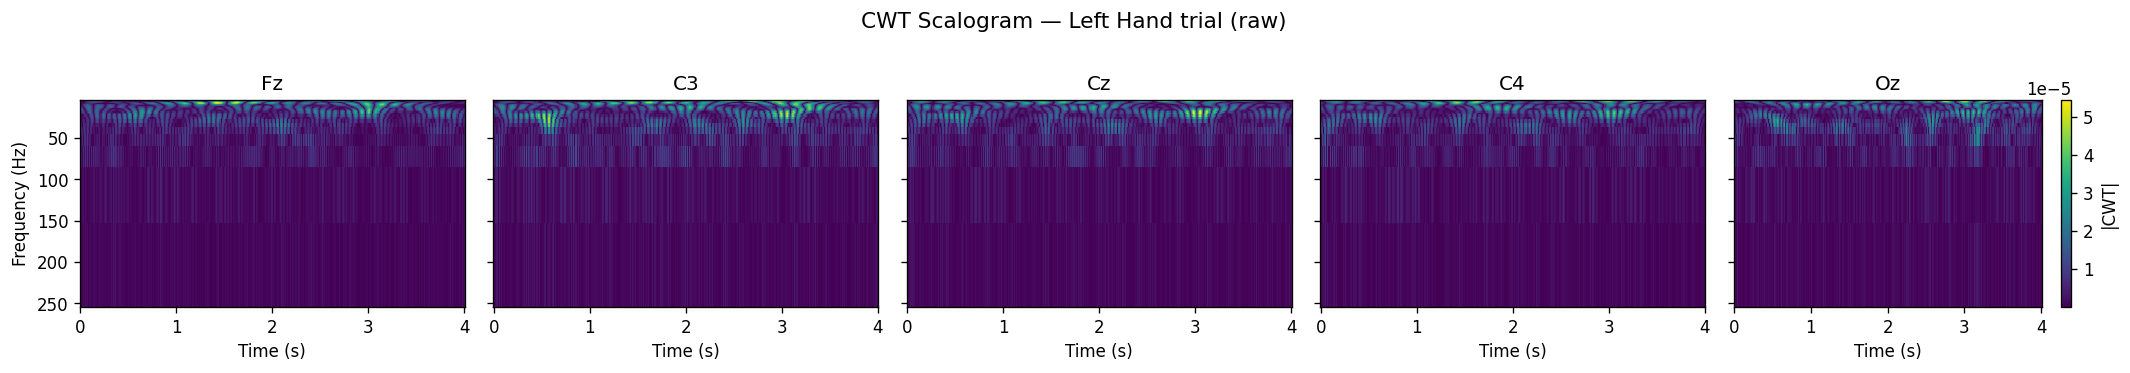

In [5]:
from scipy.signal import resample
import pywt
from config import CWT_SCALES, CWT_WAVELET

trial_raw = X_raw[y == 0][0]          
trial_sub = resample(trial_raw, N_TIME_SUBSAMPLE, axis=-1) 

scales    = np.array(CWT_SCALES, dtype=float)
freqs     = pywt.scale2frequency(CWT_WAVELET, scales) * 250 
time_axis = np.linspace(TMIN, TMAX, N_TIME_SUBSAMPLE)

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
for ch, ax in enumerate(axes):
    coeffs, _ = pywt.cwt(trial_sub[ch], scales, CWT_WAVELET)
    im = ax.pcolormesh(time_axis, freqs, np.abs(coeffs), cmap='viridis', shading='auto')
    ax.set_title(ELECTRODE_NAMES[ch].replace('EEG-', ''))
    ax.set_xlabel('Time (s)')
    ax.invert_yaxis()
    if ch == 0: ax.set_ylabel('Frequency (Hz)')

plt.suptitle('CWT Scalogram — Left Hand trial (raw)', fontsize=13, y=1.02)
plt.colorbar(im, ax=axes[-1], label='|CWT|')
plt.tight_layout(); plt.show()

In [6]:
from preprocessing import preprocess_subject, split_by_class

X_cwt, y_cwt = preprocess_subject(SUBJECT, session='T', verbose=True)
class_data   = split_by_class(X_cwt, y_cwt)
print(f'\nFull CWT dataset shape: {X_cwt.shape}')
print(f'Value range: [{X_cwt.min():.3f}, {X_cwt.max():.3f}]  (should be ≈[-1, 1])')

  Loading subject 1 session T … 

c:\Users\vchagant\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


288 trials  shape=(50, 375, 5)

Full CWT dataset shape: (288, 50, 375, 5)
Value range: [-1.000, 1.000]  (should be ≈[-1, 1])


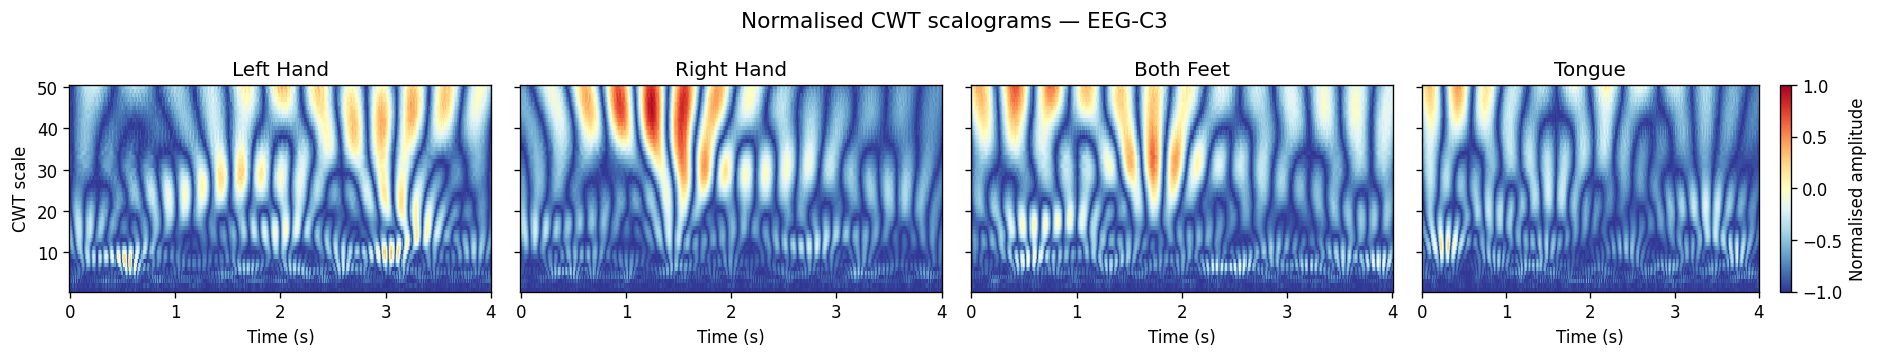

In [7]:
CH  = 1  
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
time_axis = np.linspace(TMIN, TMAX, N_TIME_SUBSAMPLE)

for cls, ax in zip(range(N_CLASSES), axes):
    sample = class_data[cls][0]         
    im = ax.pcolormesh(
        time_axis,
        np.arange(1, N_CWT_SCALES + 1),
        sample[:, :, CH],
        cmap='RdYlBu_r', vmin=-1, vmax=1, shading='auto'
    )
    ax.set_title(CLASS_NAMES[cls])
    ax.set_xlabel('Time (s)')
    ax.invert_yaxis()
    if cls == 0: ax.set_ylabel('CWT scale')

plt.suptitle(f'Normalised CWT scalograms — {ELECTRODE_NAMES[CH]}', fontsize=13)
plt.colorbar(im, ax=axes[-1], label='Normalised amplitude')
plt.tight_layout(); plt.show()

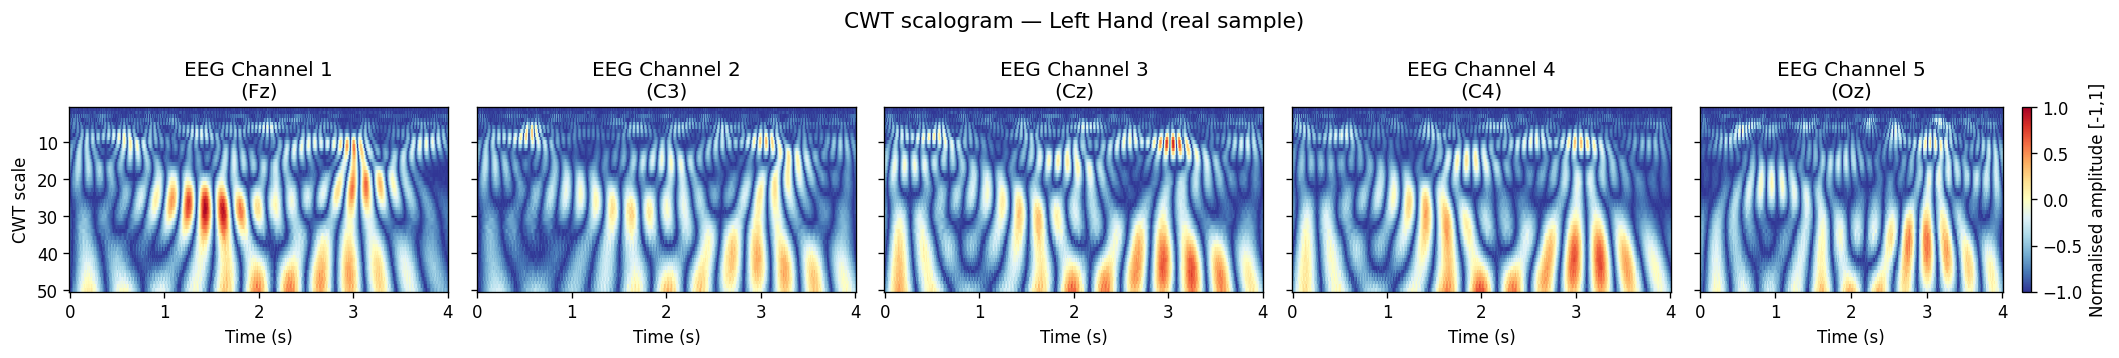

In [8]:
cls   = 0 
sample = class_data[cls][0]

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
for ch, ax in enumerate(axes):
    im = ax.pcolormesh(
        time_axis, np.arange(1, N_CWT_SCALES + 1),
        sample[:, :, ch],
        cmap='RdYlBu_r', vmin=-1, vmax=1, shading='auto'
    )
    ax.set_title(f'EEG Channel {ch+1}\n({ELECTRODE_NAMES[ch].replace("EEG-", "")})')
    ax.set_xlabel('Time (s)'); ax.invert_yaxis()
    if ch == 0: ax.set_ylabel('CWT scale')

plt.suptitle(f'CWT scalogram — {CLASS_NAMES[cls]} (real sample)', fontsize=13)
plt.colorbar(im, ax=axes[-1], label='Normalised amplitude [-1,1]')
plt.tight_layout(); plt.show()

## Augmentation Preview

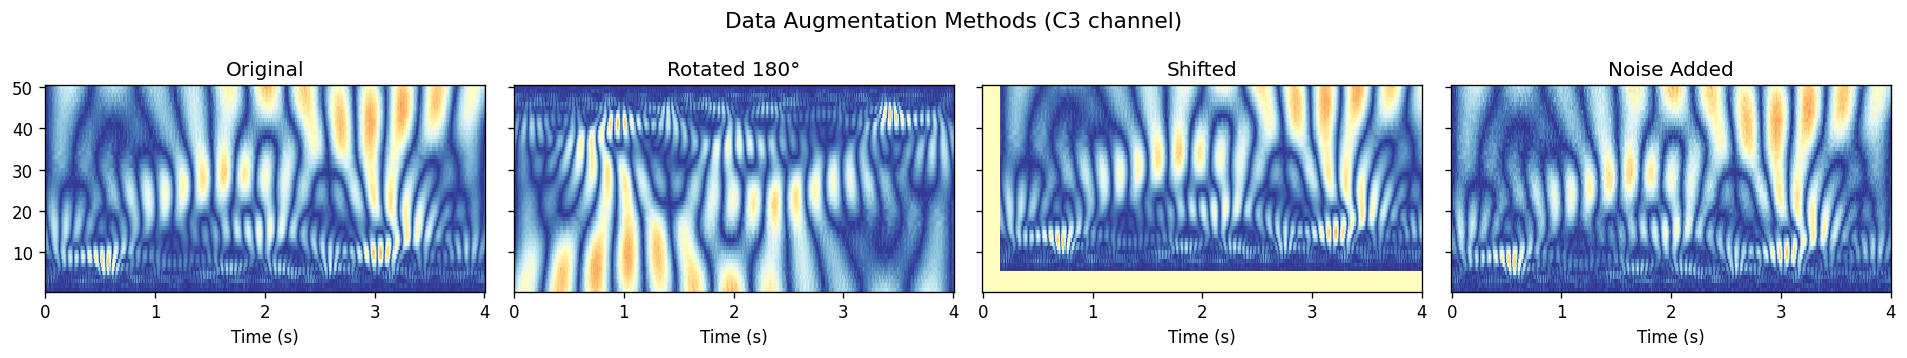

In [9]:
from augmentation import rotate_180, shift, add_gaussian_noise

original  = class_data[0][0]
rotated   = rotate_180(original)
shifted   = shift(original, delta_y=5, delta_x=15)
noisy     = add_gaussian_noise(original, alpha=0.3)

titles  = ['Original', 'Rotated 180°', 'Shifted', 'Noise Added']
samples = [original, rotated, shifted, noisy]

fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for ax, title, s in zip(axes, titles, samples):
    im = ax.pcolormesh(
        time_axis, np.arange(1, N_CWT_SCALES + 1),
        s[:, :, 1],
        cmap='RdYlBu_r', vmin=-1, vmax=1, shading='auto'
    )
    ax.set_title(title); ax.set_xlabel('Time (s)'); ax.invert_yaxis()

plt.suptitle('Data Augmentation Methods (C3 channel)', fontsize=13)
plt.tight_layout(); plt.show()